In [3]:
import pandas as pd

df = pd.read_excel("data/Online Retail.xlsx")
print("Shape:", df.shape)
df.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
print(df.isnull().sum())
print()
print("Unique customers:", df["CustomerID"].nunique())
print("Negative Quantity rows:", (df["Quantity"] < 0).sum())
print("Non-positive UnitPrice rows:", (df["UnitPrice"] <= 0).sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Unique customers: 4372
Negative Quantity rows: 10624
Non-positive UnitPrice rows: 2517


In [5]:
df = df.dropna(subset=["CustomerID"])
df["CustomerID"] = df["CustomerID"].astype(int)
print("Shape after dropping missing CustomerID:", df.shape)

Shape after dropping missing CustomerID: (406829, 8)


In [6]:
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["is_cancelled"] = df["InvoiceNo"].str.startswith("C")
print(df["is_cancelled"].value_counts())

is_cancelled
False    397924
True       8905
Name: count, dtype: int64


In [7]:
df = df[~((df["UnitPrice"] <= 0) & (~df["is_cancelled"]))]
print("Shape after removing bad-price rows:", df.shape)

Shape after removing bad-price rows: (406789, 9)


In [8]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["LineTotal"] = df["Quantity"] * df["UnitPrice"]
df[["InvoiceDate", "Quantity", "UnitPrice", "LineTotal", "is_cancelled"]].head()

,InvoiceDate,Quantity,UnitPrice,LineTotal,is_cancelled
0,2010-12-01 08:26:00,6,2.55,15.30,False
1,2010-12-01 08:26:00,6,3.39,20.34,False
2,2010-12-01 08:26:00,8,2.75,22.00,False
3,2010-12-01 08:26:00,6,3.39,20.34,False
4,2010-12-01 08:26:00,6,3.39,20.34,False


In [9]:
# snapshot_date: one day after the last transaction in the dataset,
# used as "today" to compute Recency
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

# Only real purchases count toward RFM (cancellations handled separately below)
purchases = df[~df["is_cancelled"]]

rfm = purchases.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("LineTotal", "sum"),
)
print(rfm.shape)
rfm.head()

(4338, 3)


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [10]:
# Extra behavioural features beyond plain RFM, for finer-grained segments
rfm["AvgUnitPrice"] = purchases.groupby("CustomerID")["UnitPrice"].mean()
rfm["DistinctProducts"] = purchases.groupby("CustomerID")["StockCode"].nunique()
rfm["TotalItems"] = purchases.groupby("CustomerID")["Quantity"].sum()
rfm["AvgBasketValue"] = rfm["Monetary"] / rfm["Frequency"]

rfm.head()

,Recency,Frequency,Monetary,AvgUnitPrice,DistinctProducts,TotalItems,AvgBasketValue
CustomerID,,,,,,,
12346,326,1,77183.60,1.040000,1,74215,77183.600000
12347,2,7,4310.00,2.644011,103,2458,615.714286
12348,75,4,1797.24,5.764839,22,2341,449.310000
12349,19,1,1757.55,8.289041,73,631,1757.550000
12350,310,1,334.40,3.841176,17,197,334.400000


In [11]:
# Return rate, computed from the cancelled invoices flagged earlier
returns = df[df["is_cancelled"]]
return_counts = returns.groupby("CustomerID")["InvoiceNo"].nunique()

rfm["ReturnFrequency"] = return_counts.reindex(rfm.index).fillna(0)
rfm["ReturnRate"] = rfm["ReturnFrequency"] / (rfm["Frequency"] + rfm["ReturnFrequency"])

rfm[["Frequency", "ReturnFrequency", "ReturnRate"]].describe()

,Frequency,ReturnFrequency,ReturnRate
count,4338.000000,4338.000000,4338.000000
mean,4.272015,0.834025,0.105957
std,7.697998,2.145637,0.166292
min,1.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000
50%,2.000000,0.000000,0.000000
75%,5.000000,1.000000,0.200000
max,209.000000,47.000000,0.800000


In [13]:
# Drop customers with non-positive total spend (rare net-returners),
# then save the final customer-level feature table
rfm = rfm[rfm["Monetary"] > 0].reset_index()
print("Final customer feature table:", rfm.shape)

rfm.to_csv("outputs/customer_features.csv", index=False)
rfm.describe()

Final customer feature table: (4338, 11)


,index,CustomerID,Recency,Frequency,Monetary,AvgUnitPrice,DistinctProducts,TotalItems,AvgBasketValue,ReturnFrequency,ReturnRate
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,2168.500000,15300.408022,92.536422,4.272015,2054.266460,4.467773,61.501153,1191.289073,419.166289,0.834025,0.105957
std,1252.417063,1721.808492,100.014169,7.697998,8989.230441,34.211451,85.366768,5046.081546,1796.537944,2.145637,0.166292
min,0.000000,12346.000000,1.000000,1.000000,3.750000,0.122500,1.000000,1.000000,3.450000,0.000000,0.000000
25%,1084.250000,13813.250000,18.000000,1.000000,307.415000,2.203728,16.000000,160.000000,178.625000,0.000000,0.000000
50%,2168.500000,15299.500000,51.000000,2.000000,674.485000,2.917611,35.000000,379.000000,293.900000,0.000000,0.000000
75%,3252.750000,16778.750000,142.000000,5.000000,1661.740000,3.829784,77.000000,992.750000,430.113750,1.000000,0.200000
max,4337.000000,18287.000000,374.000000,209.000000,280206.020000,2033.100000,1787.000000,196915.000000,84236.250000,47.000000,0.800000


EDA Visualization

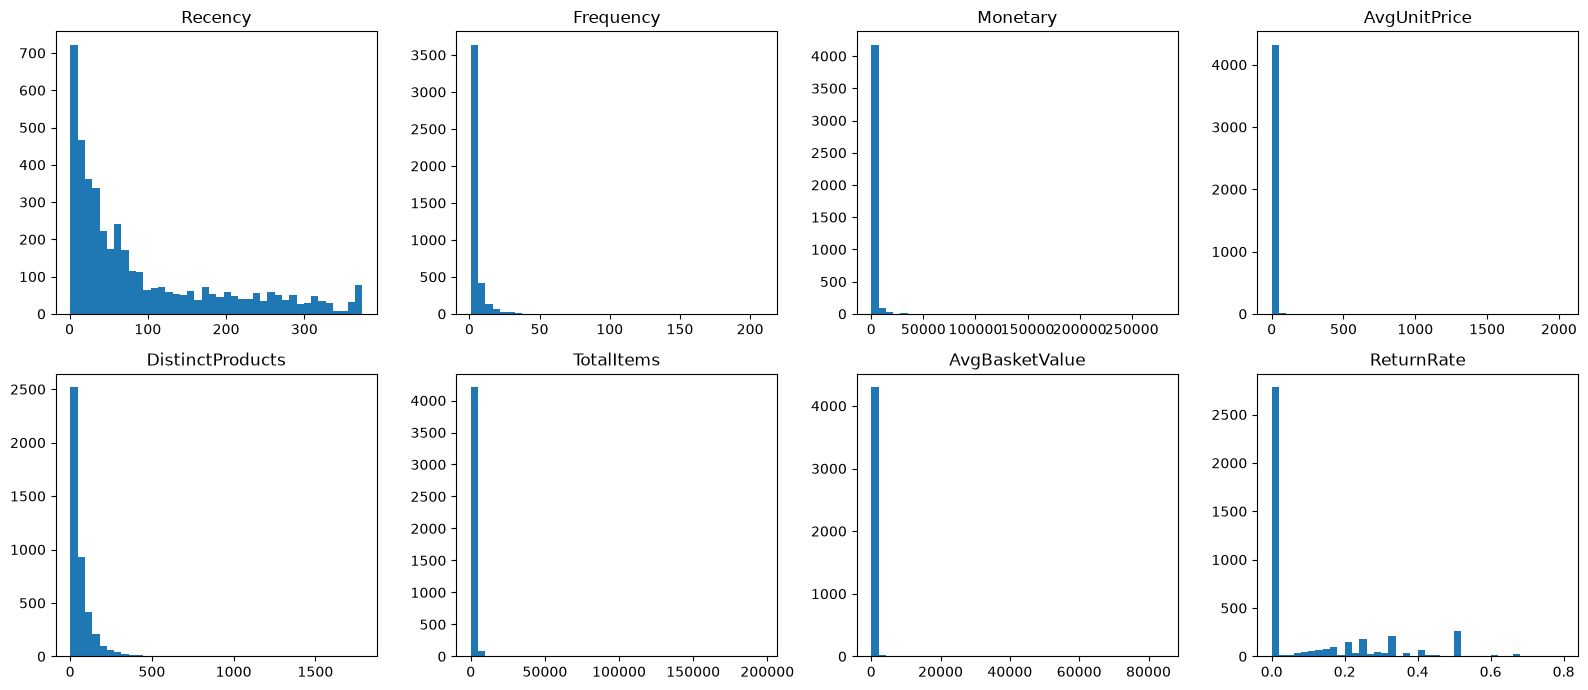

AvgUnitPrice        50.246479
AvgBasketValue      41.688126
TotalItems          20.359611
Monetary            19.324953
Frequency           12.067031
DistinctProducts     6.919445
ReturnRate           1.403983
Recency              1.246048
dtype: float64


In [14]:
import matplotlib.pyplot as plt

features = ["Recency", "Frequency", "Monetary", "AvgUnitPrice",
            "DistinctProducts", "TotalItems", "AvgBasketValue", "ReturnRate"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, features):
    ax.hist(rfm[col], bins=40)
    ax.set_title(col)
plt.tight_layout()
plt.show()

print(rfm[features].skew().sort_values(ascending=False))

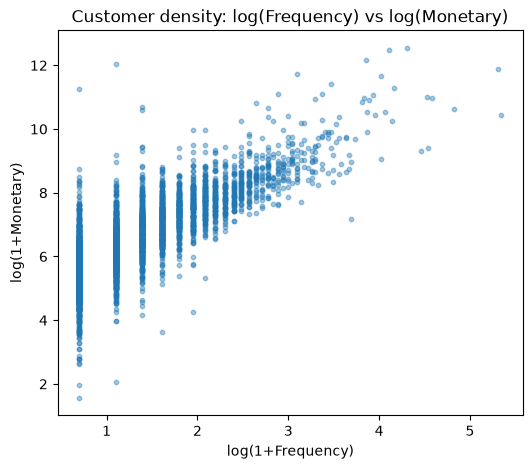

In [15]:
import numpy as np

plt.figure(figsize=(6, 5))
plt.scatter(np.log1p(rfm["Frequency"]), np.log1p(rfm["Monetary"]), s=10, alpha=0.4)
plt.xlabel("log(1+Frequency)")
plt.ylabel("log(1+Monetary)")
plt.title("Customer density: log(Frequency) vs log(Monetary)")
plt.show()

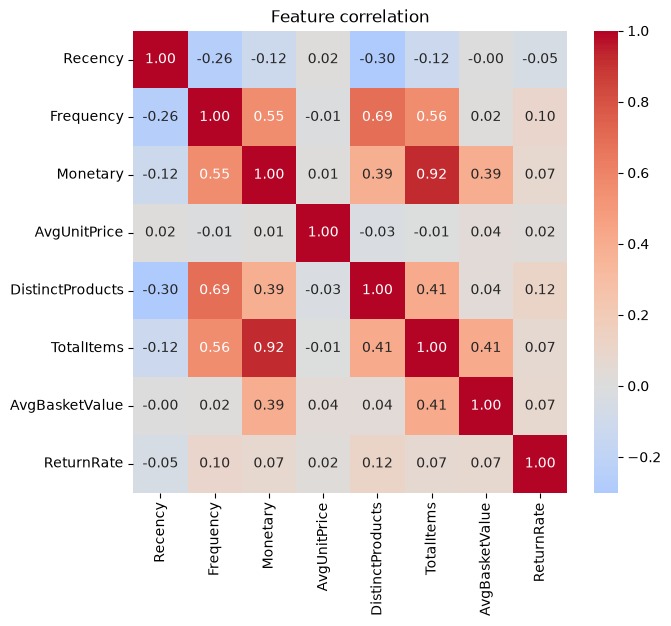

In [16]:
import seaborn as sns

plt.figure(figsize=(7, 6))
sns.heatmap(rfm[features].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation")
plt.show()

In [17]:
import numpy as np

# Only log-transform the features with heavy right-skew (skew > ~5).
# Recency and ReturnRate are left as-is -- their skew is mild.
log_features = ["Frequency", "Monetary", "AvgUnitPrice",
                 "DistinctProducts", "TotalItems", "AvgBasketValue"]

X = rfm[features].copy()  # features list from Cell 11
for col in log_features:
    X[col] = np.log1p(X[col])

X.skew().sort_values(ascending=False)

AvgUnitPrice        3.301913
ReturnRate          1.403983
Recency             1.246048
Frequency           1.208652
Monetary            0.393553
AvgBasketValue      0.234847
TotalItems          0.040961
DistinctProducts   -0.243262
dtype: float64

In [18]:
from sklearn.preprocessing import RobustScaler

# RobustScaler uses median/IQR instead of mean/std -- less thrown off by
# the extreme outliers we saw in Monetary/TotalItems even after log-transform
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)
print(X_scaled[:3])

(4338, 8)
[[ 2.21774194 -0.36907025  2.81255474 -1.58965597 -1.89719746  2.89798267
   6.35901245  2.5       ]
 [-0.39516129  0.89278926  1.10014293 -0.17636894  0.69634073  1.02596455
   0.84268336  0.        ]
 [ 0.19354839  0.46497352  0.58116499  1.33075367 -0.29407683  0.9991803
   0.48349501  0.        ]]


In [20]:
import hdbscan

In [21]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=5, metric="euclidean")
labels = clusterer.fit_predict(X_scaled)

import pandas as pd
print(pd.Series(labels).value_counts().sort_index())
print()
print("Number of clusters (excluding noise):", len(set(labels)) - (1 if -1 in labels else 0))
print("Noise ratio:", (labels == -1).mean())

-1    2375
 0      30
 1      22
 2     720
 3     370
 4     821
Name: count, dtype: int64

Number of clusters (excluding noise): 5
Noise ratio: 0.5474873213462426


In [22]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

results = []
for mcs in [15, 20, 30, 40, 60, 80]:
    for ms in [5, 10, 15, 20]:
        c = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=ms, metric="euclidean")
        lbl = c.fit_predict(X_scaled)
        n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
        noise_ratio = (lbl == -1).mean()

        if n_clusters < 2 or noise_ratio > 0.6:
            continue

        mask = lbl != -1
        if mask.sum() < 10:
            continue

        sil = silhouette_score(X_scaled[mask], lbl[mask])
        dbi = davies_bouldin_score(X_scaled[mask], lbl[mask])
        ch = calinski_harabasz_score(X_scaled[mask], lbl[mask])

        results.append({
            "min_cluster_size": mcs, "min_samples": ms,
            "n_clusters": n_clusters, "noise_ratio": round(noise_ratio, 3),
            "silhouette": round(sil, 4), "davies_bouldin": round(dbi, 4),
            "calinski_harabasz": round(ch, 1),
        })

results_df = pd.DataFrame(results).sort_values("silhouette", ascending=False)
results_df.head(15)

,min_cluster_size,min_samples,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz
3,30,5,2,0.343,0.3109,0.8322,80.0
1,15,10,2,0.320,0.3061,0.7668,46.4
4,40,5,3,0.559,0.1973,1.4616,722.9
5,60,5,3,0.559,0.1973,1.4616,722.9
6,80,5,3,0.559,0.1973,1.4616,722.9
2,20,5,5,0.547,0.0939,1.5145,421.2
0,15,5,5,0.547,0.0939,1.5145,421.2


In [23]:
results2 = []
for mcs in [18, 20, 22, 25, 28, 30, 32, 35, 38]:
    for ms in [3, 4, 5, 6, 8, 10]:
        c = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=ms, metric="euclidean")
        lbl = c.fit_predict(X_scaled)
        n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
        noise_ratio = (lbl == -1).mean()

        if n_clusters < 2:
            continue
        mask = lbl != -1
        if mask.sum() < 10:
            continue

        sil = silhouette_score(X_scaled[mask], lbl[mask])
        dbi = davies_bouldin_score(X_scaled[mask], lbl[mask])
        ch = calinski_harabasz_score(X_scaled[mask], lbl[mask])

        results2.append({
            "min_cluster_size": mcs, "min_samples": ms,
            "n_clusters": n_clusters, "noise_ratio": round(noise_ratio, 3),
            "silhouette": round(sil, 4), "davies_bouldin": round(dbi, 4),
            "calinski_harabasz": round(ch, 1),
        })

results2_df = pd.DataFrame(results2).sort_values("silhouette", ascending=False)

# Apply our business constraint: noise <= 35%, at least 3 clusters
usable = results2_df[(results2_df["noise_ratio"] <= 0.35) & (results2_df["n_clusters"] >= 3)]
print("Candidates with noise<=35% and >=3 clusters:")
print(usable.head(10))
print()
print("Overall top 10 by silhouette (for comparison):")
print(results2_df.head(10))

Candidates with noise<=35% and >=3 clusters:
Empty DataFrame
Columns: [min_cluster_size, min_samples, n_clusters, noise_ratio, silhouette, davies_bouldin, calinski_harabasz]
Index: []

Overall top 10 by silhouette (for comparison):
    min_cluster_size  min_samples  n_clusters  noise_ratio  silhouette  \
20                25            5           2        0.343      0.3109   
26                28            5           2        0.343      0.3109   
32                30            5           2        0.343      0.3109   
4                 18            8           2        0.346      0.3081   
10                20            8           2        0.346      0.3081   
15                22            6           2        0.354      0.3060   
21                25            6           2        0.354      0.3060   
3                 18            6           2        0.354      0.3060   
9                 20            6           2        0.354      0.3060   
17                22        

In [24]:
final_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=25,
    min_samples=5,
    metric="euclidean",
    prediction_data=True,
)
final_labels = final_clusterer.fit_predict(X_scaled)

rfm["cluster"] = final_labels

mask = final_labels != -1
final_metrics = {
    "silhouette": silhouette_score(X_scaled[mask], final_labels[mask]),
    "davies_bouldin": davies_bouldin_score(X_scaled[mask], final_labels[mask]),
    "calinski_harabasz": calinski_harabasz_score(X_scaled[mask], final_labels[mask]),
    "n_clusters": len(set(final_labels[mask])),
    "noise_points": int((final_labels == -1).sum()),
    "noise_ratio": float((final_labels == -1).mean()),
}
final_metrics

{'silhouette': 0.31091505604188835,
 'davies_bouldin': 0.832238712926517,
 'calinski_harabasz': 80.02592190535717,
 'n_clusters': 2,
 'noise_points': 1486,
 'noise_ratio': 0.3425541724296911}

In [25]:
profile = rfm.groupby("cluster")[features].median()
profile["count"] = rfm.groupby("cluster").size()
profile

,Recency,Frequency,Monetary,AvgUnitPrice,DistinctProducts,TotalItems,AvgBasketValue,ReturnRate,count
cluster,,,,,,,,,
-1,81.0,2.0,720.69,3.098750,25.0,412.0,299.480,0.097168,1486
0,247.0,1.0,325.60,4.131049,17.0,148.5,325.600,0.500000,30
1,40.0,2.0,660.49,2.870938,42.0,372.0,289.474,0.000000,2822


In [26]:
import umap

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(X_scaled)

rfm["umap_x"] = embedding[:, 0]
rfm["umap_y"] = embedding[:, 1]
rfm[["umap_x", "umap_y", "cluster"]].head()

c:\Users\wenxi\Miniconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,umap_x,umap_y,cluster
0,4.354921,5.747765,-1
1,6.047753,7.647217,1
2,2.758528,6.752720,-1
3,2.974226,5.948429,-1
4,0.998037,3.224508,1


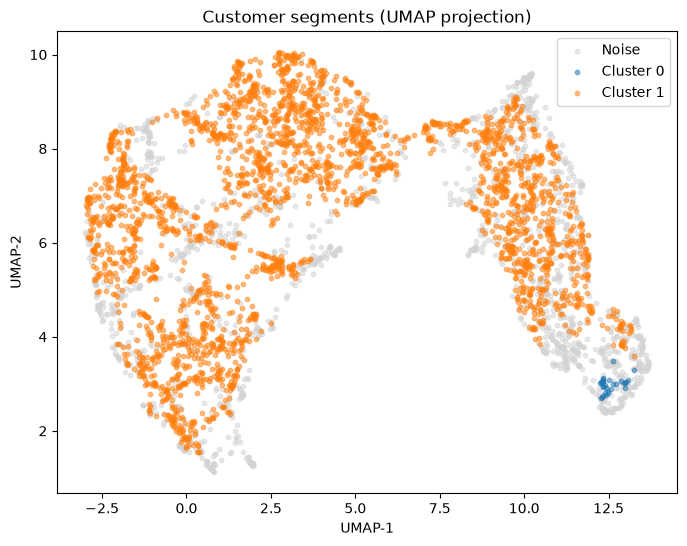

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
for cid, sub in rfm.groupby("cluster"):
    label = "Noise" if cid == -1 else f"Cluster {cid}"
    color = "lightgray" if cid == -1 else None
    plt.scatter(sub["umap_x"], sub["umap_y"], s=10, alpha=0.5, label=label, c=color)
plt.legend()
plt.title("Customer segments (UMAP projection)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

In [28]:
import joblib
import os

os.makedirs("outputs/model", exist_ok=True)

joblib.dump({
    "scaler": scaler,
    "clusterer": final_clusterer,
    "features": features,
    "log_features": log_features,
    "umap_reducer": reducer,
}, "outputs/model/clustering_pipeline.joblib")

rfm.to_csv("outputs/customer_features_clustered.csv", index=False)
print("Saved pipeline and clustered feature table.")

Saved pipeline and clustered feature table.
